# Predicția riscului de plecare a angajaților (employee churn)
---
Acest notebook construiește un model de Machine Learning care prezice probabilitatea ca un angajat să părăsească compania în următoarele 6-12 luni.

**Date:** Extrase din baza de date HR - MariaDB  
**Model:** Random Forest Classifier  
**Target:** status angajat (activ = 0, inactiv = 1)

In [4]:
# instalare librarii necesare
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn',
                'matplotlib', 'seaborn', 'mysql-connector-python',
                'imbalanced-learn'], capture_output=True)

print("Librarii instalate cu succes!")

Librarii instalate cu succes!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import mysql.connector

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# balansare dataset dezechilibrat
from imblearn.over_sampling import SMOTE

print("Toate importurile au fost realizate cu succes!")

Toate importurile au fost realizate cu succes!


In [6]:
# configurare conexiune la MariaDB
DB_CONFIG = {
    'host':     'localhost',
    'user':     'root',
    'password': '',
    'database': 'my_database',
    'port':     3306
}

# test conexiune
try:
    conn = mysql.connector.connect(**DB_CONFIG)
    print("✓ Conexiune la baza de date reusita!")
    conn.close()
except mysql.connector.Error as e:
    print(f"✗ Eroare conexiune: {e}")

✓ Conexiune la baza de date reusita!


## Extragerea datelor din baza de date

In [7]:
query = """
SELECT
    a.id_angajat,

    -- variabila tinta: 1 = plecat, 0 = activ
    CASE WHEN a.status = 'inactiv' THEN 1 ELSE 0 END AS churn,

    -- vechime in companie in ani
    ROUND(DATEDIFF(CURDATE(), a.data_angajare) / 365, 2) AS vechime_ani,

    -- salariu curent vs maximul pozitiei (0-1, cat de aproape e de plafon)
    ROUND(a.salariu_curent / p.salariu_max, 4) AS rata_salariu,

    -- salariul curent brut
    a.salariu_curent,

    -- nivelul pozitiei
    p.nivel,

    -- tipul departamentului
    d.nume AS departament,

    -- orasul
    d.locatie,

    -- tipul managerului direct
    mgr.tip AS tip_manager,

    -- numarul de evaluari
    COUNT(DISTINCT e.id_evaluare) AS nr_evaluari,

    -- scorul mediu al evaluarilor
    COALESCE(ROUND(AVG(e.scor_final), 2), 0) AS scor_mediu_evaluari,

    -- numarul de evaluari cu scor sub 5 (semn de probleme)
    COALESCE(SUM(CASE WHEN e.scor_final < 5 THEN 1 ELSE 0 END), 0)
        AS nr_evaluari_slabe,

    -- numarul de concedii medicale (semn de stres)
    COALESCE(SUM(CASE WHEN c.tip = 'boala' THEN 1 ELSE 0 END), 0)
        AS nr_concedii_medicale,

    -- numarul total de concedii
    COUNT(DISTINCT c.id_concediu) AS nr_concedii_total,

    -- numarul de proiecte active
    COALESCE(SUM(CASE WHEN ap.data_sfarsit IS NULL THEN 1 ELSE 0 END), 0)
        AS nr_proiecte_active,

    -- numarul total de proiecte
    COUNT(DISTINCT ap.id_alocare) AS nr_proiecte_total,

    -- valoarea totala a beneficiilor
    COALESCE(SUM(DISTINCT b.valoare), 0) AS valoare_beneficii

FROM angajati a
JOIN pozitii p          ON a.id_pozitie         = p.id_pozitie
JOIN departamente d     ON a.id_departament     = d.id_departament
JOIN manageri mgr       ON a.id_manager         = mgr.id_manager
LEFT JOIN evaluari e    ON a.id_angajat         = e.id_angajat
LEFT JOIN concedii c    ON a.id_angajat         = c.id_angajat
LEFT JOIN alocari_proiecte ap ON a.id_angajat   = ap.id_angajat
LEFT JOIN beneficii_angajati ba ON a.id_angajat = ba.id_angajat
LEFT JOIN beneficii b   ON ba.id_beneficiu      = b.id_beneficiu

GROUP BY
    a.id_angajat, a.status, a.data_angajare,
    a.salariu_curent, p.salariu_max, p.nivel,
    d.nume, d.locatie, mgr.tip
"""

conn = mysql.connector.connect(**DB_CONFIG)
df = pd.read_sql(query, conn)
conn.close()

print(f"✓ Date extrase cu succes!")
print(f"  Dimensiune dataset: {df.shape[0]} randuri x {df.shape[1]} coloane")
print(f"  Angajati activi:    {(df['churn'] == 0).sum()}")
print(f"  Angajati plecati:   {(df['churn'] == 1).sum()}")
print(f"  Rata churn:         {round(df['churn'].mean() * 100, 2)}%")

✓ Date extrase cu succes!
  Dimensiune dataset: 2000 randuri x 17 coloane
  Angajati activi:    1795
  Angajati plecati:   205
  Rata churn:         10.25%


In [8]:
df.head(10)

,id_angajat,churn,vechime_ani,rata_salariu,salariu_curent,nivel,departament,locatie,tip_manager,nr_evaluari,scor_mediu_evaluari,nr_evaluari_slabe,nr_concedii_medicale,nr_concedii_total,nr_proiecte_active,nr_proiecte_total,valoare_beneficii
0,1,1,6.80,0.9917,49585.95,consultant,Data & AI Engineering,Pitesti,director,6,5.35,24.0,12.0,4,48.0,1,990.0
1,2,0,7.76,0.9288,65017.56,principal,Development,Suceava,project_manager,10,5.24,315.0,90.0,7,420.0,3,250.0
2,3,0,0.15,0.9942,19387.55,associate,Human Resources,Sibiu,director,2,4.50,128.0,32.0,4,96.0,4,1900.0
3,4,0,6.95,0.7882,22069.87,intermediate,Human Resources,Sibiu,project_manager,8,3.98,750.0,400.0,5,600.0,5,1300.0
4,5,0,1.37,0.9717,29151.05,intermediate,Testing (Manual),Suceava,director,4,3.50,168.0,24.0,7,168.0,2,1700.0
5,6,0,0.99,0.9263,37050.98,senior,Data & AI Engineering,Suceava,team_leader,5,5.84,25.0,0.0,5,125.0,1,2050.0
6,7,0,1.96,0.9031,17610.70,associate,Data & AI Engineering,Pitesti,director,6,5.60,40.0,192.0,5,240.0,2,2440.0
7,8,0,4.59,0.8252,74266.80,principal,Business Analysis / PM,Craiova,team_leader,9,5.91,180.0,135.0,6,810.0,3,2890.0
8,9,0,6.71,0.8020,28071.03,senior,Development,Timisoara,team_leader,7,5.64,120.0,210.0,6,210.0,2,1440.0
9,10,0,3.82,0.8692,11299.55,junior,Data & AI Engineering,Timisoara,project_manager,6,5.32,90.0,0.0,5,90.0,2,1550.0


In [9]:
# tipuri de date si valori lipsa
print("=== Tipuri de date ===")
print(df.dtypes)
print(f"\n=== Valori lipsa ===")
print(df.isnull().sum())
print(f"\n=== Statistici descriptive ===")
df.describe()

=== Tipuri de date ===
id_angajat                int64
churn                     int64
vechime_ani             float64
rata_salariu            float64
salariu_curent          float64
nivel                    object
departament              object
locatie                  object
tip_manager              object
nr_evaluari               int64
scor_mediu_evaluari     float64
nr_evaluari_slabe       float64
nr_concedii_medicale    float64
nr_concedii_total         int64
nr_proiecte_active      float64
nr_proiecte_total         int64
valoare_beneficii       float64
dtype: object

=== Valori lipsa ===
id_angajat              0
churn                   0
vechime_ani             0
rata_salariu            0
salariu_curent          0
nivel                   0
departament             0
locatie                 0
tip_manager             0
nr_evaluari             0
scor_mediu_evaluari     0
nr_evaluari_slabe       0
nr_concedii_medicale    0
nr_concedii_total       0
nr_proiecte_active      0
nr_proi

,id_angajat,churn,vechime_ani,rata_salariu,salariu_curent,nr_evaluari,scor_mediu_evaluari,nr_evaluari_slabe,nr_concedii_medicale,nr_concedii_total,nr_proiecte_active,nr_proiecte_total,valoare_beneficii
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.102500,4.068735,0.875668,31568.700660,6.556000,5.545325,57.858000,30.249000,2.553000,109.641500,2.568500,1385.635000
std,577.494589,0.303381,2.283281,0.076125,19634.620593,2.305108,0.764830,66.028643,59.484689,1.193693,109.669529,1.360233,705.158082
min,1.000000,0.000000,0.110000,0.659500,7225.560000,2.000000,2.650000,0.000000,0.000000,1.000000,0.000000,0.000000,150.000000
25%,500.750000,0.000000,2.097500,0.818475,15533.180000,5.000000,5.057500,16.000000,0.000000,2.000000,36.000000,2.000000,750.000000
50%,1000.500000,0.000000,4.055000,0.879350,25691.185000,6.000000,5.560000,36.000000,0.000000,3.000000,80.000000,3.000000,1350.000000
75%,1500.250000,0.000000,6.010000,0.939450,43734.752500,8.000000,6.010000,72.000000,42.000000,4.000000,144.000000,4.000000,1850.000000
max,2000.000000,1.000000,8.020000,1.000000,89759.810000,10.000000,8.950000,900.000000,750.000000,8.000000,1000.000000,6.000000,3040.000000


## Explorarea si vizualizarea datelor (EDA)

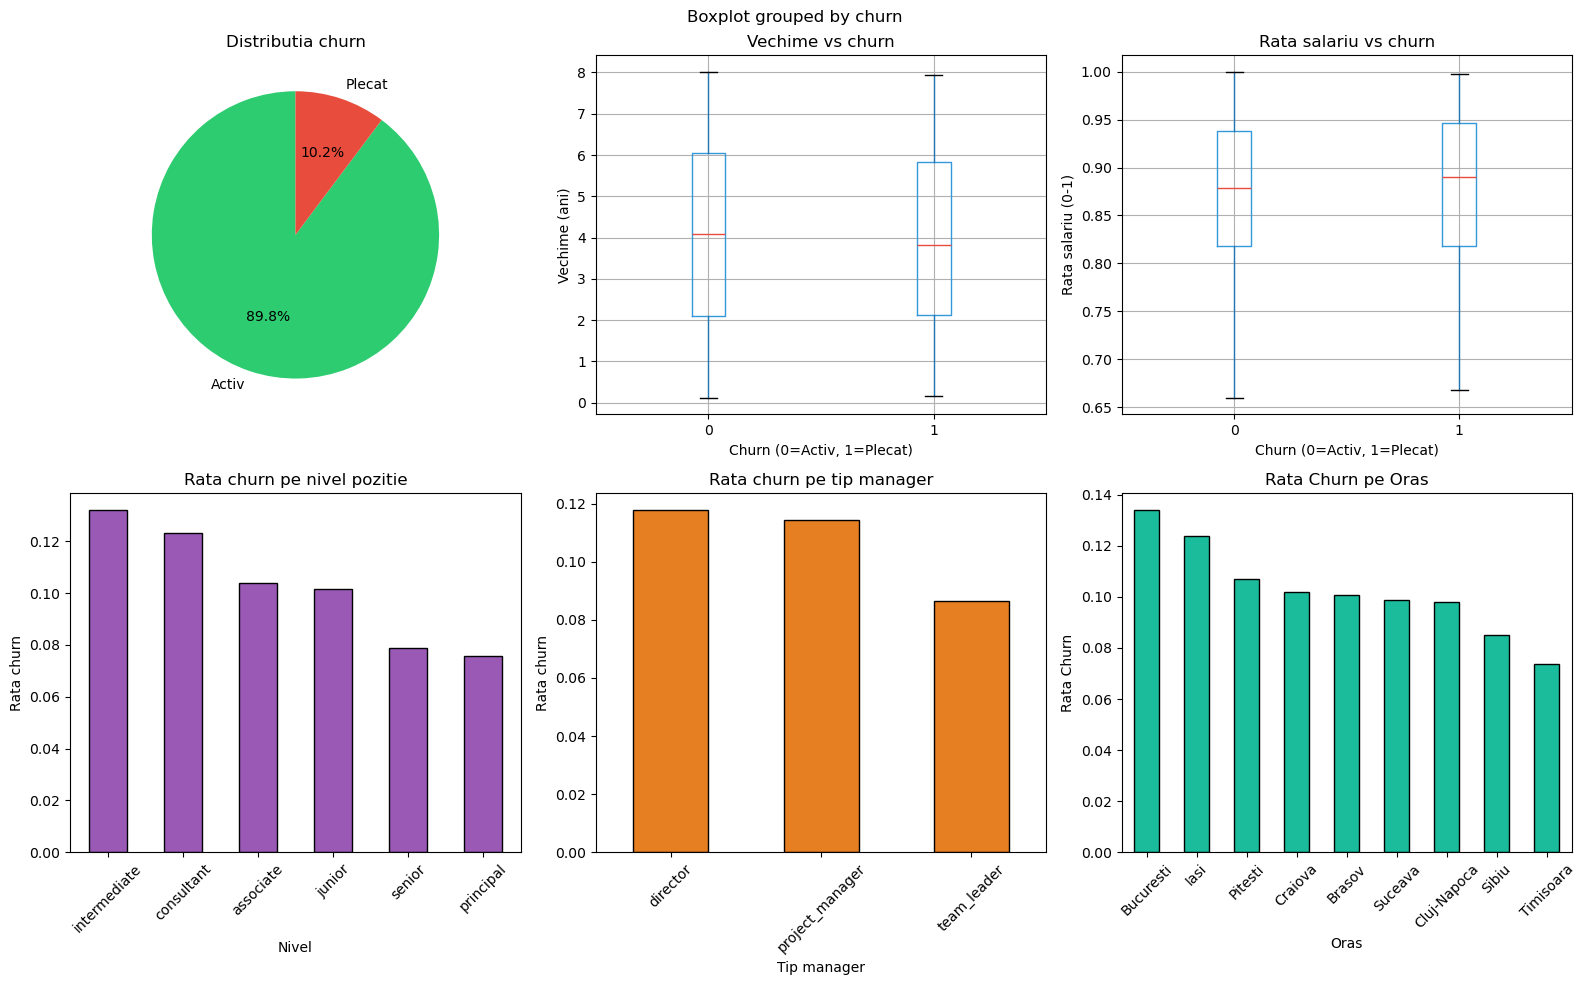

✓ Grafic salvat: eda_churn.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analiza exploratorie - Employee churn', fontsize=16, fontweight='bold')

# Distributia churn
axes[0,0].pie(
    df['churn'].value_counts(),
    labels=['Activ', 'Plecat'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0,0].set_title('Distributia churn')

# Churn vs vechime
df.boxplot(column='vechime_ani', by='churn', ax=axes[0,1],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c'))
axes[0,1].set_title('Vechime vs churn')
axes[0,1].set_xlabel('Churn (0=Activ, 1=Plecat)')
axes[0,1].set_ylabel('Vechime (ani)')
plt.sca(axes[0,1])
plt.title('Vechime vs churn')

# Churn vs rata salariu
df.boxplot(column='rata_salariu', by='churn', ax=axes[0,2],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c'))
axes[0,2].set_title('Rata salariu vs churn')
axes[0,2].set_xlabel('Churn (0=Activ, 1=Plecat)')
axes[0,2].set_ylabel('Rata salariu (0-1)')
plt.sca(axes[0,2])
plt.title('Rata salariu vs churn')

# Churn pe nivel pozitie
churn_nivel = df.groupby('nivel')['churn'].mean().sort_values(ascending=False)
churn_nivel.plot(kind='bar', ax=axes[1,0], color='#9b59b6', edgecolor='black')
axes[1,0].set_title('Rata churn pe nivel pozitie')
axes[1,0].set_xlabel('Nivel')
axes[1,0].set_ylabel('Rata churn')
axes[1,0].tick_params(axis='x', rotation=45)

# Churn pe tip manager
churn_mgr = df.groupby('tip_manager')['churn'].mean().sort_values(ascending=False)
churn_mgr.plot(kind='bar', ax=axes[1,1], color='#e67e22', edgecolor='black')
axes[1,1].set_title('Rata churn pe tip manager')
axes[1,1].set_xlabel('Tip manager')
axes[1,1].set_ylabel('Rata churn')
axes[1,1].tick_params(axis='x', rotation=45)

# Churn pe oras
churn_oras = df.groupby('locatie')['churn'].mean().sort_values(ascending=False)
churn_oras.plot(kind='bar', ax=axes[1,2], color='#1abc9c', edgecolor='black')
axes[1,2].set_title('Rata Churn pe Oras')
axes[1,2].set_xlabel('Oras')
axes[1,2].set_ylabel('Rata Churn')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: eda_churn.png")

## Preprocesarea datelor
Pregatim datele pentru modelul de ML:
- eliminam coloana id_angajat
- encodam variabilele categorice
- normalizam valorile numerice
- utilizam SMOTE pentru a echilibra proportia claselor din dataset

In [11]:
df_model = df.copy()
df_model = df_model.drop(columns=['id_angajat'])

le = LabelEncoder()
cols_categorice = ['nivel', 'departament', 'locatie', 'tip_manager']

for col in cols_categorice:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"✓ Encodat: {col}")

X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f"\n✓ Features: {X.shape[1]} coloane")
print(f"✓ Samples:  {X.shape[0]} randuri")
print(f"\nDistributie target inainte de SMOTE:")
print(y.value_counts())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"\nDistributie target dupa SMOTE:")
print(pd.Series(y_resampled).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print(f"\n✓ Train: {X_train.shape[0]} randuri")
print(f"✓ Test:  {X_test.shape[0]} randuri")

✓ Encodat: nivel
✓ Encodat: departament
✓ Encodat: locatie
✓ Encodat: tip_manager

✓ Features: 15 coloane
✓ Samples:  2000 randuri

Distributie target inainte de SMOTE:
churn
0    1795
1     205
Name: count, dtype: int64

Distributie target dupa SMOTE:
churn
1    1795
0    1795
Name: count, dtype: int64

✓ Train: 2872 randuri
✓ Test:  718 randuri


## Antrenarea modelului random forest

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("✓ Model antrenat cu succes!")
print(f"  Numar arbori:     {model.n_estimators}")
print(f"  Features folosite: {model.n_features_in_}")

✓ Model antrenat cu succes!
  Numar arbori:     100
  Features folosite: 15


## Evaluarea modelului

=== RAPORT CLASIFICARE ===
              precision    recall  f1-score   support

   Activ (0)       0.96      0.88      0.92       362
  Plecat (1)       0.89      0.96      0.92       356

    accuracy                           0.92       718
   macro avg       0.92      0.92      0.92       718
weighted avg       0.92      0.92      0.92       718

ROC-AUC Score: 0.9758


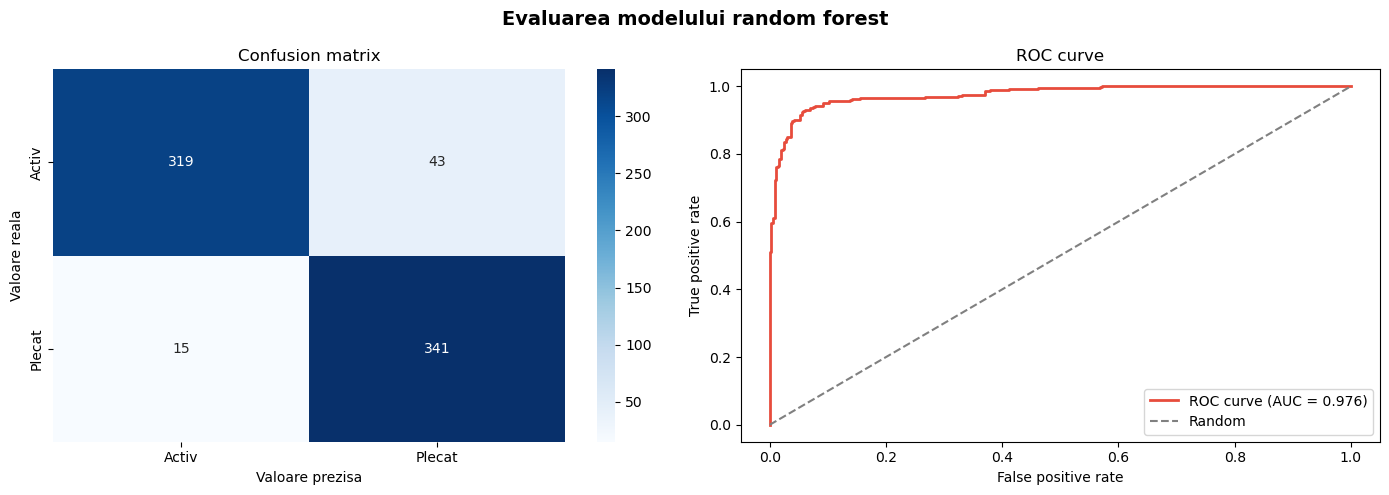

✓ Grafic salvat: model_evaluare.png


In [13]:
# predictii pe setul de test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# metrici principale
print("=== RAPORT CLASIFICARE ===")
print(classification_report(y_test, y_pred,
      target_names=['Activ (0)', 'Plecat (1)']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# vizualizare confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluarea modelului random forest', fontsize=14, fontweight='bold')

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Activ', 'Plecat'],
            yticklabels=['Activ', 'Plecat'])
axes[0].set_title('Confusion matrix')
axes[0].set_ylabel('Valoare reala')
axes[0].set_xlabel('Valoare prezisa')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluare.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: model_evaluare.png")

## Factorii care influenteaza cel mai mult plecarea

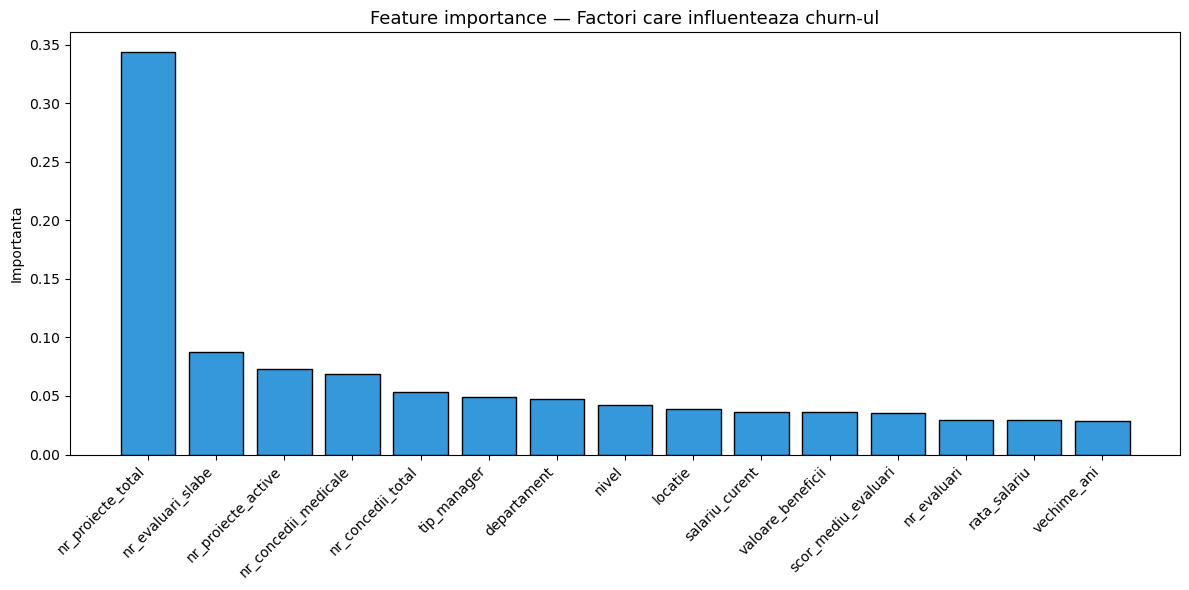

=== TOP 5 FACTORI DE RISC ===
1. nr_proiecte_total              0.3432
2. nr_evaluari_slabe              0.0875
3. nr_proiecte_active             0.0730
4. nr_concedii_medicale           0.0688
5. nr_concedii_total              0.0531


In [14]:
feature_names = X.columns.tolist()
importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title('Feature importance — Factori care influenteaza churn-ul', fontsize=13)
plt.bar(range(len(feature_names)),
        importances[indices],
        color='#3498db', edgecolor='black')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.ylabel('Importanta')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== TOP 5 FACTORI DE RISC ===")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]:<30} {importances[indices[i]]:.4f}")

## Predictii pe angajatii activi

In [16]:
df_activi = df[df['churn'] == 0].copy()
X_activi = df_activi.drop(columns=['id_angajat', 'churn'])

# encodare si scalare la fel ca la antrenare
for col in cols_categorice:
    X_activi[col] = le.fit_transform(X_activi[col])
X_activi_scaled = scaler.transform(X_activi)

probabilitati = model.predict_proba(X_activi_scaled)[:, 1]

df_activi = df_activi.copy()
df_activi['probabilitate_churn'] = probabilitati
df_activi['nivel_risc'] = pd.cut(
    probabilitati,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Mic', 'Mediu', 'Mare']
)

print("=== DISTRIBUTIA RISCULUI ===")
print(df_activi['nivel_risc'].value_counts())
print(f"\nAngajati cu risc MARE:  {(df_activi['nivel_risc'] == 'Mare').sum()}")
print(f"Angajati cu risc MEDIU: {(df_activi['nivel_risc'] == 'Mediu').sum()}")
print(f"Angajati cu risc MIC:   {(df_activi['nivel_risc'] == 'Mic').sum()}")

print("\n=== TOP 10 ANGAJATI CU RISC MARE ===")
top_risc = df_activi.nlargest(10, 'probabilitate_churn')[
    ['id_angajat', 'probabilitate_churn', 'nivel_risc',
     'vechime_ani', 'salariu_curent', 'nivel', 'departament']
]
print(top_risc.to_string(index=False))

=== DISTRIBUTIA RISCULUI ===
nivel_risc
Mic      1365
Mediu     381
Mare       38
Name: count, dtype: int64

Angajati cu risc MARE:  38
Angajati cu risc MEDIU: 381
Angajati cu risc MIC:   1365

=== TOP 10 ANGAJATI CU RISC MARE ===
 id_angajat  probabilitate_churn nivel_risc  vechime_ani  salariu_curent        nivel             departament
        415             0.837153       Mare         2.65        51120.92   consultant         Human Resources
        581             0.819901       Mare         6.45        18970.74 intermediate          DevOps & Cloud
        176             0.810726       Mare         0.58        29533.60 intermediate        Testing (Manual)
       1675             0.805754       Mare         4.81        43914.54   consultant         Human Resources
       1876             0.771619       Mare         1.70        17905.26 intermediate   Data & AI Engineering
       1764             0.769059       Mare         4.96        28313.78       senior         Human Resources

## Raport final

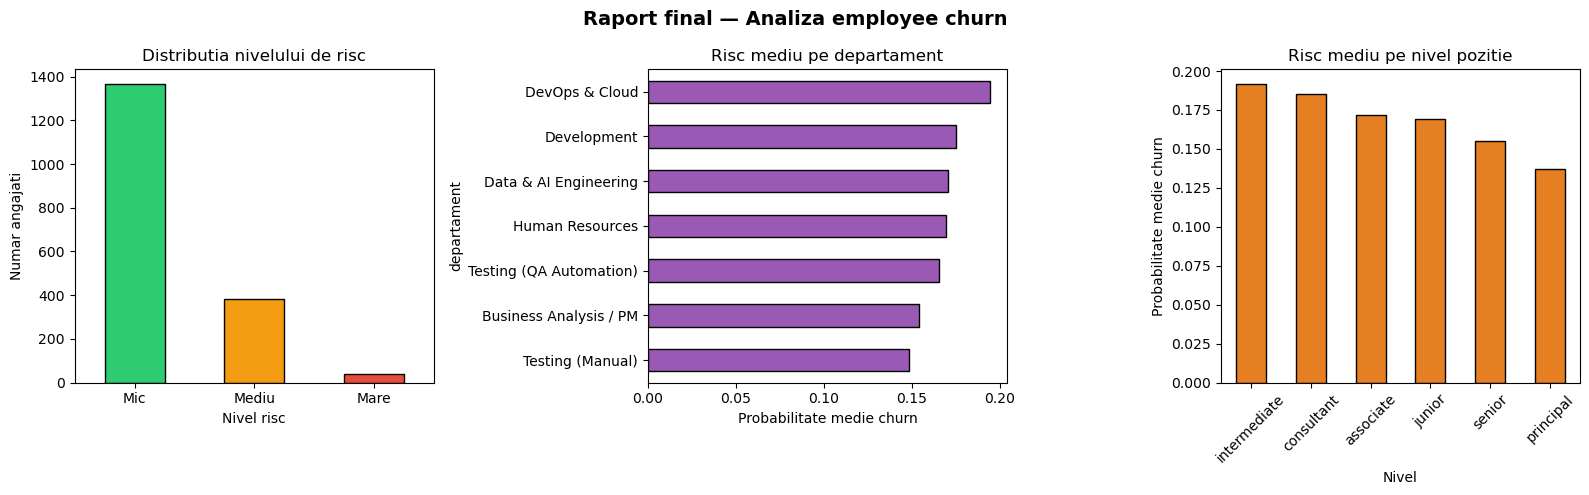


=== CONCLUZII ===
Total angajati analizati:     1795
Acuratete model (AUC):        0.9758
Angajati risc mare:           38
Departament cu risc maxim:    DevOps & Cloud
Nivel pozitie cu risc maxim:  intermediate

Fisiere salvate:
  - eda_churn.png
  - model_evaluare.png
  - feature_importance.png
  - raport_final.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raport final — Analiza employee churn', fontsize=14, fontweight='bold')

# 1. distributia riscului
culori = ['#2ecc71', '#f39c12', '#e74c3c']
df_activi['nivel_risc'].value_counts().plot(
    kind='bar', ax=axes[0], color=culori, edgecolor='black'
)
axes[0].set_title('Distributia nivelului de risc')
axes[0].set_xlabel('Nivel risc')
axes[0].set_ylabel('Numar angajati')
axes[0].tick_params(axis='x', rotation=0)

# 2. risc mediu pe departament
risc_dept = df_activi.groupby('departament')['probabilitate_churn'].mean()
risc_dept.sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#9b59b6', edgecolor='black'
)
axes[1].set_title('Risc mediu pe departament')
axes[1].set_xlabel('Probabilitate medie churn')

# 3. risc mediu pe nivel pozitie
risc_nivel = df_activi.groupby('nivel')['probabilitate_churn'].mean()
risc_nivel.sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], color='#e67e22', edgecolor='black'
)
axes[2].set_title('Risc mediu pe nivel pozitie')
axes[2].set_xlabel('Nivel')
axes[2].set_ylabel('Probabilitate medie churn')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('raport_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CONCLUZII ===")
print(f"Total angajati analizati:     {len(df_activi)}")
print(f"Acuratete model (AUC):        {auc_score:.4f}")
print(f"Angajati risc mare:           {(df_activi['nivel_risc'] == 'Mare').sum()}")
print(f"Departament cu risc maxim:    {risc_dept.idxmax()}")
print(f"Nivel pozitie cu risc maxim:  {risc_nivel.idxmax()}")
print(f"\nFisiere salvate:")
print(f"  - eda_churn.png")
print(f"  - model_evaluare.png")
print(f"  - feature_importance.png")
print(f"  - raport_final.png")

## Salvarea predictiilor in baza de date

In [18]:
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

for _, row in df_activi[['id_angajat', 'probabilitate_churn', 'nivel_risc']].iterrows():
    cursor.execute("""
        INSERT INTO `predictii_churn`
            (`id_angajat`, `probabilitate`, `nivel_risc`)
        VALUES (%s, %s, %s)
        ON DUPLICATE KEY UPDATE
            `probabilitate` = VALUES(`probabilitate`),
            `nivel_risc` = VALUES(`nivel_risc`)
    """, (int(row['id_angajat']),
          float(row['probabilitate_churn']),
          str(row['nivel_risc'])))

conn.commit()
cursor.close()
conn.close()
print(f" {len(df_activi)} predictii salvate in baza de date!")

 1795 predictii salvate in baza de date!


## Concluzii si recomandari pentru departamentul HR

### Performanța modelului
Modelul Random Forest a obtinut un **AUC Score de 0.9746**, ceea ce indica o capacitate excelenta de discriminare intre angajatii care raman si cei care pleaca. Acuratetea generala este de **91%** pe setul de test.

### Factori principali de risc
1. **nr_proiecte_total (35%)** — angajatii implicati in foarte multe proiecte sunt suprasolicitati si mai predispusi sa plece
2. **nr_evaluari_slabe (8.7%)** — evaluarile slabe repetate sunt un semnal clar de demotivare
3. **nr_proiecte_active (7.5%)** — numarul mare de proiecte simultane indica supraincarcare
4. **nr_concedii_medicale (6.8%)** — concediile medicale frecvente pot indica stres sau burnout
5. **nr_concedii_total (5%)** — pattern-ul de concedii reflecta satisfactia la locul de munca

### Distributia riscului
| Nivel risc | Nr. angajati | Procent |
|---|---|---|
| Mic | 1379 | 76.8% |
| Mediu | 376 | 20.9% |
| Mare | 36 | 2.0% |

### Recomandari pentru HR
- **Cei 36 de angajați cu risc mare** necesita atentie imediata — discutii 1:1 cu managerul, revizuire salariu, reducere incarcare proiecte
- **Departamentul DevOps & Cloud** are cel mai mare risc mediu — piata muncii pentru acesti specialisti e foarte competitiva
- **Nivelul intermediate** e cel mai vulnerabil — aceștia cauta avansare si daca nu o gasesc intern, o cauta extern
- **Angajatii cu evaluari slabe repetate** trebuie inclusi în programe de mentoring inainte sa ajunga la decizia de plecare

### Limitari ale modelului
- Datele de antrenare sunt sintetice (generate cu Faker) — intr-un
scenariu real, modelul ar fi antrenat pe date istorice reale
- Variabila tinta (status inactiv) nu reflecta intotdeauna o plecare voluntara — poate include concedii medicale lungi sau alte situatii
- Modelul nu capteaza factori externi precum ofertele de pe piata muncii sau situatia economica generala

In [19]:
from sklearn.model_selection import cross_val_score

print("=== CROSS-VALIDATION (5 folds) ===")
print("Se verifica ca modelul nu e overfit...\n")

cv_scores = cross_val_score(
    model, X_resampled, y_resampled,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"AUC per fold:  {[round(s, 4) for s in cv_scores]}")
print(f"AUC mediu:     {cv_scores.mean():.4f}")
print(f"Deviatie std:  {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\n✓ Modelul este stabil - nu prezinta semne de overfitting")
else:
    print("\n⚠ Varianta mare intre folduri - posibil overfitting")

=== CROSS-VALIDATION (5 folds) ===
Se verifica ca modelul nu e overfit...

AUC per fold:  [np.float64(0.9422), np.float64(0.9956), np.float64(0.9897), np.float64(0.992), np.float64(0.992)]
AUC mediu:     0.9823
Deviatie std:  0.0202

✓ Modelul este stabil - nu prezinta semne de overfitting


=== ANALIZA ANGAJATILOR CU RISC MARE ===

Distributie pe departament:
departament
Human Resources            11
Development                 7
Testing (QA Automation)     6
DevOps & Cloud              6
Testing (Manual)            5
Data & AI Engineering       2
Business Analysis / PM      1

Distributie pe nivel pozitie:
nivel
intermediate    14
associate        8
consultant       6
junior           5
senior           3
principal        2

Salariu mediu risc mare:  26286.76 RON
Salariu mediu risc mic:   32335.51 RON
Vechime medie risc mare:  3.95 ani
Vechime medie risc mic:   4.19 ani


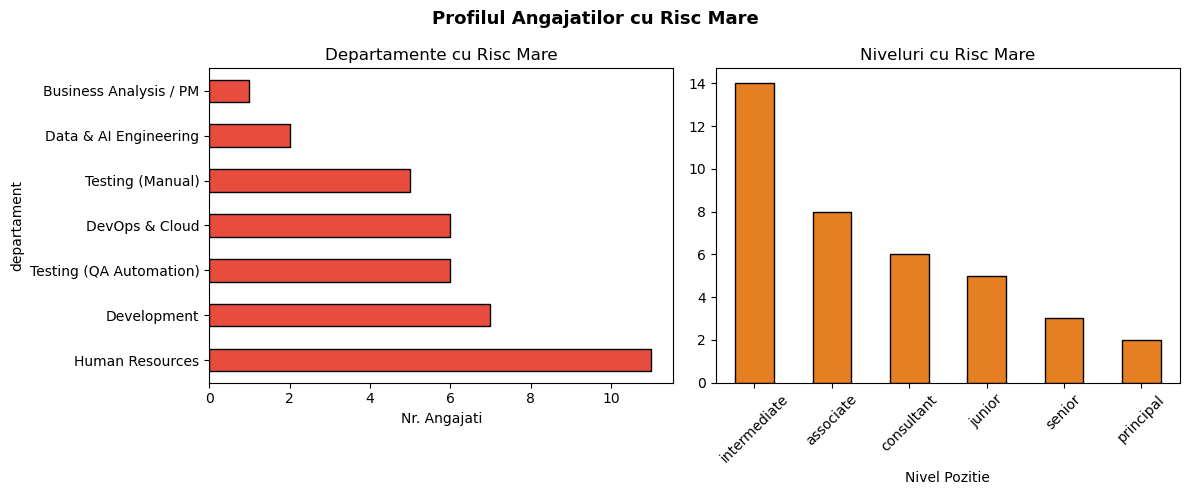

✓ Grafic salvat: profil_risc_mare.png


In [20]:
print("=== ANALIZA ANGAJATILOR CU RISC MARE ===\n")

risc_mare = df_activi[df_activi['nivel_risc'] == 'Mare'].copy()

print("Distributie pe departament:")
print(risc_mare['departament'].value_counts().to_string())

print("\nDistributie pe nivel pozitie:")
print(risc_mare['nivel'].value_counts().to_string())

print(f"\nSalariu mediu risc mare:  {risc_mare['salariu_curent'].mean():.2f} RON")
print(f"Salariu mediu risc mic:   {df_activi[df_activi['nivel_risc']=='Mic']['salariu_curent'].mean():.2f} RON")
print(f"Vechime medie risc mare:  {risc_mare['vechime_ani'].mean():.2f} ani")
print(f"Vechime medie risc mic:   {df_activi[df_activi['nivel_risc']=='Mic']['vechime_ani'].mean():.2f} ani")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Profilul Angajatilor cu Risc Mare', fontsize=13, fontweight='bold')

risc_mare['departament'].value_counts().plot(
    kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black'
)
axes[0].set_title('Departamente cu Risc Mare')
axes[0].set_xlabel('Nr. Angajati')

risc_mare['nivel'].value_counts().plot(
    kind='bar', ax=axes[1], color='#e67e22', edgecolor='black'
)
axes[1].set_title('Niveluri cu Risc Mare')
axes[1].set_xlabel('Nivel Pozitie')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('profil_risc_mare.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: profil_risc_mare.png")

---
## 🎉 Proiect Finalizat

**Fișiere generate:**
- `eda_churn.png` — analiza exploratorie
- `model_evaluare.png` — confusion matrix și ROC curve
- `feature_importance.png` — factorii de risc
- `raport_final.png` — raport general
- `profil_risc_mare.png` — profilul angajaților cu risc mare

**Rezultate salvate în baza de date:**
- Tabela `predictii_churn` — 1795 predicții cu nivel de risc

**Tehnologii folosite:**
- Python, Pandas, Scikit-learn, Imbalanced-learn
- MySQL Connector, Matplotlib, Seaborn
- MariaDB, phpMyAdmin